In [7]:
import math
import heapq
import copy
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.measure import label, regionprops
from numba import jit, prange
from skimage import io

In [31]:
### --- Perona-Malik Diffusion --- ###
def compute_gradients(image):
    grad_north = np.zeros_like(image)
    grad_south = np.zeros_like(image)
    grad_east = np.zeros_like(image)
    grad_west = np.zeros_like(image)

    grad_north[:-1] = image[1:] - image[:-1]
    grad_south[1:] = image[:-1] - image[1:]
    grad_east[:, :-1] = image[:, 1:] - image[:, :-1]
    grad_west[:, 1:] = image[:, :-1] - image[:, 1:]
    return grad_north, grad_south, grad_east, grad_west

def perona_malik_conduction(gradients, kappa, method='quadratic'):
    if method == 'quadratic':
        return [np.exp(-(g / kappa)**2) for g in gradients]
    elif method == 'exponential':
        return [1. / (1. + (g / kappa)**2) for g in gradients]
    raise ValueError("Invalid conduction method.")

@jit(nopython=True, parallel=True)
def update_image(image, gradients, conductance, delta_t):
    result = np.zeros_like(image)
    for i in prange(1, image.shape[0] - 1):
        for j in prange(1, image.shape[1] - 1):
            total = 0.0
            for d in range(4):
                total += conductance[d][i, j] * gradients[d][i, j]
            result[i, j] = total  # Assign the total to result[i, j]
    return np.clip(image + delta_t * result, 0, 255)


def perona_malik(image, iterations=20, delta_t=0.1, kappa=20, method='quadratic'):
    image = image.astype(np.float64)
    for _ in range(iterations):
        grads = compute_gradients(image)
        conds = perona_malik_conduction(grads, kappa, method)
        image = update_image(image, grads, conds, delta_t)
    return image.astype(np.uint8)

### --- Grey Weighted Distance Transform --- ###
INF = np.finfo(np.float32).max
ALIVE, TRIAL, FAR = -1, 0, 1

def initialize_gwdt(image):
    mean_val = np.mean(image)
    state = np.full_like(image, FAR, dtype=np.int8)
    dist_map = np.full_like(image, INF, dtype=np.float32)
    mask = image < mean_val
    dist_map[mask] = image[mask].astype(float)
    state[mask] = ALIVE
    return state, dist_map

def gwdt(image):
    state, dist = initialize_gwdt(image)
    pq = []
    rows, cols = image.shape

    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            if state[i, j] == FAR and np.any(state[i-1:i+2, j-1:j+2] == ALIVE):
                state[i, j] = TRIAL
                dist[i, j] = float(image[i, j])
                heapq.heappush(pq, (dist[i, j], i, j))

    while pq:
        d, i, j = heapq.heappop(pq)
        for di, dj in [(-1,0), (1,0), (0,-1), (0,1), (-1,-1), (-1,1), (1,-1), (1,1)]:
            ni, nj = i + di, j + dj
            if 0 <= ni < rows and 0 <= nj < cols:
                cost = d + image[ni, nj] * math.hypot(di, dj)
                if dist[ni, nj] > cost:
                    dist[ni, nj] = cost
                    state[ni, nj] = TRIAL
                    heapq.heappush(pq, (cost, ni, nj))

    dist[dist == INF] = 0
    dist = (dist / (np.max(dist) + 1)) * 255 if np.max(dist) > 0 else np.zeros_like(dist)
    return dist.astype(np.uint8)

### --- Chan-Vese Active Contour --- ###
def apply_operation(matrix, op):
    func = {'atan': np.arctan, 'sqrt': np.sqrt}[op]
    return np.vectorize(func)(matrix)

def CV(LSF, img, mu, nu, eps, step):
    Drc = (eps / np.pi) / (eps**2 + LSF**2)
    Hea = 0.5 * (1 + (2 / np.pi) * apply_operation(LSF / eps, "atan"))
    Iy, Ix = np.gradient(LSF)
    s = apply_operation(Ix**2 + Iy**2, "sqrt")
    Nx, Ny = Ix / (s + 1e-6), Iy / (s + 1e-6)
    _, Nxx = np.gradient(Nx)
    Nyy, _ = np.gradient(Ny)
    curv = Nxx + Nyy

    length_term = nu * Drc * curv
    laplace = cv2.Laplacian(LSF, cv2.CV_64F)
    penalty_term = mu * (laplace - curv)

    C1 = np.sum(Hea * img) / np.sum(Hea)
    C2 = np.sum((1 - Hea) * img) / np.sum(1 - Hea)
    cv_term = Drc * (-(img - C1)**2 + (img - C2)**2)

    return LSF + step * (length_term + penalty_term + cv_term)


def visualize_images(images, titles, suptitle=None):
    fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))
    # Ensure the number of images and titles match
    if len(images) != len(titles):
        print("Warning: Number of images and titles do not match.")
        return

    # Adjust axes to be iterable even if there's only one image
    if len(images) == 1:
        axes = [axes]

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap='gray')
        ax.set_title(title)
        ax.axis('off')
    if suptitle:
        plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()


In [32]:
#image_path = "celltest1.tif"
#mask_path = "Maskcelltest1.tif"
image_path = "celltest1.tif"
mask_path = "Maskcelltest1.tif"
save_path = "test-cell-segment.tif"

image = io.imread(image_path, as_gray = True)
mask = io.imread(mask_path, as_gray = True)

num_iter = 100
mult_factor = 0.5
mu = 0.1#1
nu = 0.1 #0.003 * 255**2
eps = 0.1
step = 0.1
log_progress = False

nr, nc = image.shape
label_image, lab_num = label(mask, background=None, return_num=True, connectivity=2)
final_seg = copy.deepcopy(mask)
lab_num

17

In [33]:
#working_image = image # choosing image without perona and gwdt

#patch_filtered = perona_malik(image, iterations=30) # using perona
#working_image = patch_filtered # choosing with perona without gwdt

#patch_gwdt = gwdt(image) #using Gwdt
#working_image = patch_gwdt # choosing GWDT without Perona

#combining gwdt and perona
patch_filtered = perona_malik(image, iterations=30) #
patch_gwdt = gwdt(patch_filtered)
working_image = patch_gwdt # choosing GWDT without Perona

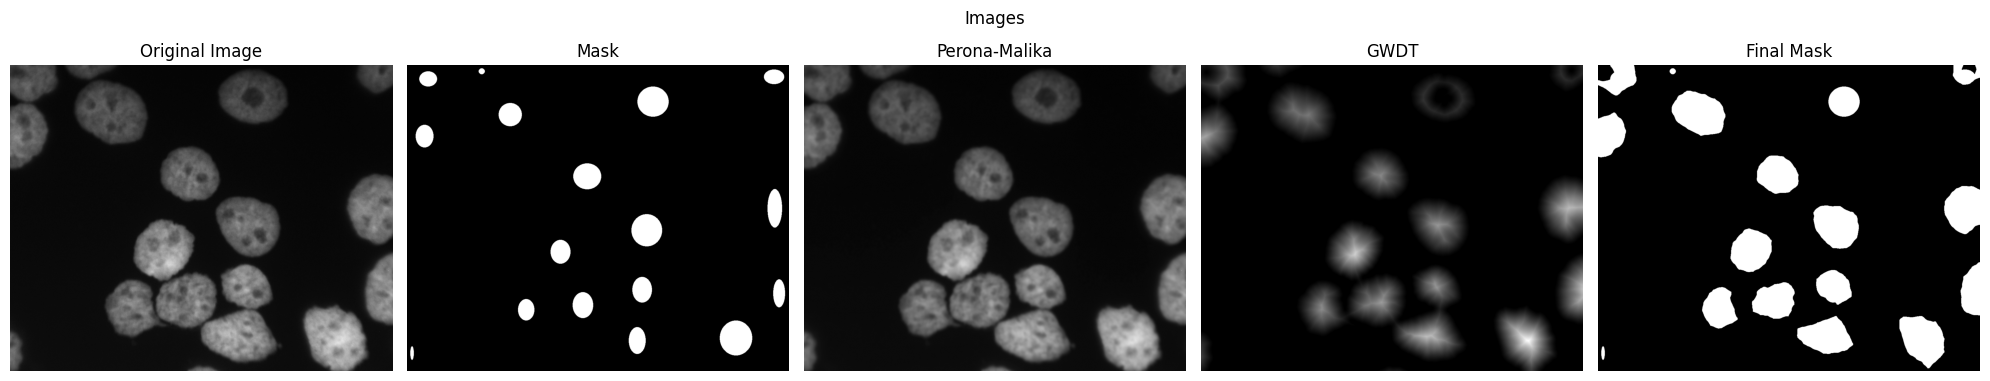

In [34]:
for k in range(num_iter):
    hasupdate = 0
    # Re-label mask each iteration if needed, or process based on initial mask
    # Processing based on initial mask and accumulating results seems more likely
    labeled_mask_current = label(final_seg) # Use the original mask to define regions each time
    regions = regionprops(labeled_mask_current)

    if not regions: # Add a check in case label(mask) returns no regions
        print("No regions found based on the initial mask. Exiting segmentation.")
        break

    for kount, region in enumerate(regions):
        minr, minc, maxr, maxc = region.bbox
        h = maxr - minr
        w = maxc - minc

        # Expand bounding box
        # Ensure mult_factor scales the difference, not the max value itself
        minr_exp = int(max(0, minr - mult_factor * h))
        maxr_exp = int(min(nr, maxr + mult_factor * h))
        minc_exp = int(max(0, minc - mult_factor * w))
        maxc_exp = int(min(nc, maxc + mult_factor * w))
        if log_progress:
            print("k", k, "i: ", kount, " label", region.label, " dim: ", minr_exp, minc_exp, maxr_exp, maxc_exp, end="")

        image_curr = copy.deepcopy(working_image)
        final_seg_curr = copy.deepcopy(final_seg)

        final_seg_curr[labeled_mask_current != region.label] = 0

        patch = working_image[minr_exp:maxr_exp, minc_exp:maxc_exp]
        mask_patch = final_seg_curr[minr_exp:maxr_exp, minc_exp:maxc_exp]

        if patch.shape[0] == 0 or patch.shape[1] == 0:
            continue # Skip empty patches

        LSF = np.ones_like(patch, dtype=np.float64)
        LSF[mask_patch > 0] = -1 # Inside the initial mask is where we want to segment
        patch_float = patch.astype(np.float64)
        LSF_next = CV(LSF, patch_float, mu, nu, eps, step)

        new_seg_patch = (LSF_next < 0).astype(np.uint8)
        new_seg_patch = cv2.morphologyEx(new_seg_patch, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
        loc_lab = label(new_seg_patch)
        loc_lab_props = regionprops(loc_lab)
        loc_lab_lb = 0
        for loc_lab_prop in loc_lab_props:
            rc, cc = loc_lab_prop.centroid
            rc = int(rc)
            cc = int(cc)
            # print(rc, cc)
            if LSF[rc, cc] == -1:
                loc_lab_lb = loc_lab_prop.label
                a1, a2, b1, b2 = loc_lab_prop.bbox
                # print(loc_lab_prop.image_filled)
                new_seg_patch[loc_lab != loc_lab_lb] = 0
                new_seg_patch[a1:b1, a2:b2][loc_lab_prop.image_filled] = 1
                break

        new_seg_patch = np.uint8(new_seg_patch * 255)
        # if log_progress:
        #     io.imsave("nn"+"_"+str(k)+"_"+str(kount)+".tif", new_seg_patch)

        neighborhood_found = False
        ctrl_patch = final_seg[minr_exp:maxr_exp, minc_exp:maxc_exp]
        ctrl_patch = copy.deepcopy(ctrl_patch)
        _, ctrl_num = label(ctrl_patch, background=None, return_num=True, connectivity=2)
        ctrl_patch |= new_seg_patch
        _, ctrl_num_next = label(ctrl_patch, background=None, return_num=True, connectivity=2)
        neighborhood_found = ctrl_num_next < ctrl_num

        if not neighborhood_found:
            final_seg[minr_exp:maxr_exp, minc_exp:maxc_exp] |= new_seg_patch
            hasupdate = 1

        if log_progress:
            print(' ', neighborhood_found, ctrl_num_next, ctrl_num)

    # io.imsave("ff" + "_" + str(k) + ".tif", final_seg)
    # Check if any region was updated in this iteration
    if hasupdate == 0:
        print("No updates in this iteration. Breaking.")
        break # Exit the main iteration loop if no updates occurred


io.imsave(save_path, final_seg)
visualize_images([image, mask, patch_filtered, working_image, final_seg], ["Original Image", "Mask", "Perona-Malika", "GWDT", "Final Mask"], "Images")

In [35]:
import numpy as np
from skimage.io import imread
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_segmentation(pred_mask, gt_mask):
    """
    Вычисление precision, recall и F1 между предсказанной и эталонной маской.

    Parameters:
    - pred_mask: бинарное изображение предсказанной маски (0 или 255)
    - gt_mask: бинарное изображение эталонной маски (0 или 255)

    Returns:
    - precision, recall, f1: значения метрик
    """
    # Преобразуем в булевы векторы (1 - белый пиксель)
    pred_flat = (pred_mask.flatten() > 0).astype(np.uint8)
    gt_flat = (gt_mask.flatten() > 0).astype(np.uint8)

    precision = precision_score(gt_flat, pred_flat)
    recall = recall_score(gt_flat, pred_flat)
    f1 = f1_score(gt_flat, pred_flat)

    return precision, recall, f1


# Пути к изображениям
gt_mask_path = "Maskcelltest1.tif"           # эталонная маска (ground truth)
predicted_mask_path = "test-cell-segment.tif"  # результат сегментации

# Загрузка изображений (предположительно 8-битные TIFF или PNG)
gt = imread(gt_mask_path, as_gray=True)
pred = imread(predicted_mask_path, as_gray=True)

# Бинаризация, если нужно
gt_bin = (gt > 127).astype(np.uint8) * 255
pred_bin = (pred > 127).astype(np.uint8) * 255

# Вычисление метрик
precision, recall, f1 = evaluate_segmentation(pred_bin, gt_bin)

# Вывод результатов
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-score:  {f1:.2f}")

Precision: 0.40
Recall:    1.00
F1-score:  0.57


In [36]:
import numpy as np
from skimage.io import imread
from skimage.transform import resize

def compute_metrics(pred_mask, gt_mask):
    """
    Расчёт precision, recall, F1 по формулам
    на основе бинарных масок.
    """

    # Бинаризация на случай 0-255
    pred = (pred_mask > 0).astype(np.uint8)
    gt = (gt_mask > 0).astype(np.uint8)

    # Вычисляем TP, FP, FN
    TP = np.sum((pred == 1) & (gt == 1))
    FP = np.sum((pred == 1) & (gt == 0))
    FN = np.sum((pred == 0) & (gt == 1))

    # Формулы
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    return precision, recall, f1


gt = imread("normal_28.tif", as_gray=True)
pred = imread("test-cell-segment.tif", as_gray=True)

# Приводим predicted к размеру ground truth
#pred_resized = resize(pred, gt.shape, order=0, preserve_range=True).astype(np.uint8)

# Затем продолжаем:
#pred_bin = (pred_resized > 127).astype(np.uint8)
#gt_bin = (gt > 127).astype(np.uint8)

#precision, recall, f1 = compute_metrics(pred_bin, gt_bin)
#print(f"Precision: {precision:.3f}")
#print(f"Recall:    {recall:.3f}")
#print(f"F1 Score:  {f1:.3f}")

# бинаризуем
gt_bin = (gt > 127).astype(np.uint8)
pred_bin = (pred > 127).astype(np.uint8)

precision, recall, f1 = compute_metrics(pred_bin, gt_bin)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")

Precision: 0.364
Recall:    0.736
F1 Score:  0.487


In [41]:
import numpy as np
from skimage.io import imread
from sklearn.metrics import jaccard_score
from scipy.stats import pearsonr

def binarize_image(gray_img, threshold=127):
    """Бинаризация серого изображения."""
    return (gray_img > threshold).astype(np.uint8)

def compute_iou(pred_mask, intensity_img, threshold=127):
    """Вычисление IoU между маской и пороговым интенсивным изображением."""
    intensity_bin = binarize_image(intensity_img, threshold)
    pred_bin = (pred_mask > 0).astype(np.uint8)

    intersection = np.logical_and(pred_bin, intensity_bin).sum()
    union = np.logical_or(pred_bin, intensity_bin).sum()

    iou = intersection / union if union > 0 else 0.0
    return iou

def compute_correlation(pred_mask, intensity_img):
    """Вычисление коэффициента корреляции между маской и интенсивностями."""
    pred_flat = pred_mask.flatten().astype(np.float64)
    intensity_flat = intensity_img.flatten().astype(np.float64)

    # Маску нормируем в [0, 1]
    pred_flat = pred_flat / 255.0 if pred_flat.max() > 1 else pred_flat

    corr, _ = pearsonr(pred_flat, intensity_flat)
    return corr


# Пути к файлам
result_mask_path = "test-cell-segment.tif"
intensity_image_path = "celltest1.tif"

# Загрузка
mask = imread(result_mask_path, as_gray=True)
intensity = imread(intensity_image_path, as_gray=True)

# Вычисления
iou = compute_iou(mask, intensity, threshold=127)
corr = compute_correlation(mask, intensity)

print(f"IoU (с интенсивными структурами): {iou:.3f}")
print(f"Корреляция (маска vs интенсивность): {corr:.3f}")

IoU (с интенсивными структурами): 0.323
Корреляция (маска vs интенсивность): 0.684


All the Code In ONE **BLOCK**

In [ ]:
import math
import heapq
import copy
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.measure import label, regionprops
from numba import jit, prange
from skimage import io

### --- Perona-Malik Diffusion --- ###
def compute_gradients(image):
    grad_north = np.zeros_like(image)
    grad_south = np.zeros_like(image)
    grad_east = np.zeros_like(image)
    grad_west = np.zeros_like(image)

    grad_north[:-1] = image[1:] - image[:-1]
    grad_south[1:] = image[:-1] - image[1:]
    grad_east[:, :-1] = image[:, 1:] - image[:, :-1]
    grad_west[:, 1:] = image[:, :-1] - image[:, 1:]
    return grad_north, grad_south, grad_east, grad_west

def perona_malik_conduction(gradients, kappa, method='quadratic'):
    if method == 'quadratic':
        return [np.exp(-(g / kappa)**2) for g in gradients]
    elif method == 'exponential':
        return [1. / (1. + (g / kappa)**2) for g in gradients]
    raise ValueError("Invalid conduction method.")

@jit(nopython=True, parallel=True)
def update_image(image, gradients, conductance, delta_t):
    result = np.zeros_like(image)
    for i in prange(1, image.shape[0] - 1):
        for j in prange(1, image.shape[1] - 1):
            total = 0.0
            for d in range(4):
                total += conductance[d][i, j] * gradients[d][i, j]
            result[i, j] = total  # Assign the total to result[i, j]
    return np.clip(image + delta_t * result, 0, 255)


def perona_malik(image, iterations=20, delta_t=0.1, kappa=20, method='quadratic'):
    image = image.astype(np.float64)
    for _ in range(iterations):
        grads = compute_gradients(image)
        conds = perona_malik_conduction(grads, kappa, method)
        image = update_image(image, grads, conds, delta_t)
    return image.astype(np.uint8)

### --- Grey Weighted Distance Transform --- ###
INF = np.finfo(np.float32).max
ALIVE, TRIAL, FAR = -1, 0, 1

def initialize_gwdt(image):
    mean_val = np.mean(image)
    state = np.full_like(image, FAR, dtype=np.int8)
    dist_map = np.full_like(image, INF, dtype=np.float32)
    mask = image < mean_val
    dist_map[mask] = image[mask].astype(float)
    state[mask] = ALIVE
    return state, dist_map

def gwdt(image):
    state, dist = initialize_gwdt(image)
    pq = []
    rows, cols = image.shape

    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            if state[i, j] == FAR and np.any(state[i-1:i+2, j-1:j+2] == ALIVE):
                state[i, j] = TRIAL
                dist[i, j] = float(image[i, j])
                heapq.heappush(pq, (dist[i, j], i, j))

    while pq:
        d, i, j = heapq.heappop(pq)
        for di, dj in [(-1,0), (1,0), (0,-1), (0,1), (-1,-1), (-1,1), (1,-1), (1,1)]:
            ni, nj = i + di, j + dj
            if 0 <= ni < rows and 0 <= nj < cols:
                cost = d + image[ni, nj] * math.hypot(di, dj)
                if dist[ni, nj] > cost:
                    dist[ni, nj] = cost
                    state[ni, nj] = TRIAL
                    heapq.heappush(pq, (cost, ni, nj))

    dist[dist == INF] = 0
    dist = (dist / (np.max(dist) + 1)) * 255 if np.max(dist) > 0 else np.zeros_like(dist)
    return dist.astype(np.uint8)

### --- Chan-Vese Active Contour --- ###
def apply_operation(matrix, op):
    func = {'atan': np.arctan, 'sqrt': np.sqrt}[op]
    return np.vectorize(func)(matrix)

def CV(LSF, img, mu, nu, eps, step):
    Drc = (eps / np.pi) / (eps**2 + LSF**2)
    Hea = 0.5 * (1 + (2 / np.pi) * apply_operation(LSF / eps, "atan"))
    Iy, Ix = np.gradient(LSF)
    s = apply_operation(Ix**2 + Iy**2, "sqrt")
    Nx, Ny = Ix / (s + 1e-6), Iy / (s + 1e-6)
    _, Nxx = np.gradient(Nx)
    Nyy, _ = np.gradient(Ny)
    curv = Nxx + Nyy

    length_term = nu * Drc * curv
    laplace = cv2.Laplacian(LSF, cv2.CV_64F)
    penalty_term = mu * (laplace - curv)

    C1 = np.sum(Hea * img) / np.sum(Hea)
    C2 = np.sum((1 - Hea) * img) / np.sum(1 - Hea)
    cv_term = Drc * (-(img - C1)**2 + (img - C2)**2)

    return LSF + step * (length_term + penalty_term + cv_term)


def visualize_images(images, titles, suptitle=None):
    fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))
    # Ensure the number of images and titles match
    if len(images) != len(titles):
        print("Warning: Number of images and titles do not match.")
        return

    # Adjust axes to be iterable even if there's only one image
    if len(images) == 1:
        axes = [axes]

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap='gray')
        ax.set_title(title)
        ax.axis('off')
    if suptitle:
        plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

image_path = "cell1.tif"
mask_path = "cell1mask.tif"
save_path = "test-cell-segment.tif"

image = io.imread(image_path, as_gray = True)
mask = io.imread(mask_path, as_gray = True)

num_iter = 100
mult_factor = 0.5
mu = 0.1#1
nu = 0.1 #0.003 * 255**2
eps = 0.1
step = 0.1
log_progress = False

#working_image = image # choosing image without perona and gwdt

#patch_filtered = perona_malik(image, iterations=30) # using perona
#working_image = patch_filtered # choosing with perona without gwdt

#patch_gwdt = gwdt(image) #using Gwdt
#working_image = patch_gwdt # choosing GWDT without Perona

#combining gwdt and perona
patch_filtered = perona_malik(image, iterations=30) #
patch_gwdt = gwdt(patch_filtered)
working_image = patch_gwdt # choosing GWDT without Perona

for k in range(num_iter):
    hasupdate = 0
    # Re-label mask each iteration if needed, or process based on initial mask
    # Processing based on initial mask and accumulating results seems more likely
    labeled_mask_current = label(final_seg) # Use the original mask to define regions each time
    regions = regionprops(labeled_mask_current)

    if not regions: # Add a check in case label(mask) returns no regions
        print("No regions found based on the initial mask. Exiting segmentation.")
        break

    for kount, region in enumerate(regions):
        minr, minc, maxr, maxc = region.bbox
        h = maxr - minr
        w = maxc - minc

        # Expand bounding box
        # Ensure mult_factor scales the difference, not the max value itself
        minr_exp = int(max(0, minr - mult_factor * h))
        maxr_exp = int(min(nr, maxr + mult_factor * h))
        minc_exp = int(max(0, minc - mult_factor * w))
        maxc_exp = int(min(nc, maxc + mult_factor * w))
        if log_progress:
            print("k", k, "i: ", kount, " label", region.label, " dim: ", minr_exp, minc_exp, maxr_exp, maxc_exp, end="")

        image_curr = copy.deepcopy(working_image)
        final_seg_curr = copy.deepcopy(final_seg)

        final_seg_curr[labeled_mask_current != region.label] = 0

        patch = working_image[minr_exp:maxr_exp, minc_exp:maxc_exp]
        mask_patch = final_seg_curr[minr_exp:maxr_exp, minc_exp:maxc_exp]

        if patch.shape[0] == 0 or patch.shape[1] == 0:
            continue # Skip empty patches

        LSF = np.ones_like(patch, dtype=np.float64)
        LSF[mask_patch > 0] = -1 # Inside the initial mask is where we want to segment
        patch_float = patch.astype(np.float64)
        LSF_next = CV(LSF, patch_float, mu, nu, eps, step)

        new_seg_patch = (LSF_next < 0).astype(np.uint8)
        new_seg_patch = cv2.morphologyEx(new_seg_patch, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
        loc_lab = label(new_seg_patch)
        loc_lab_props = regionprops(loc_lab)
        loc_lab_lb = 0
        for loc_lab_prop in loc_lab_props:
            rc, cc = loc_lab_prop.centroid
            rc = int(rc)
            cc = int(cc)
            # print(rc, cc)
            if LSF[rc, cc] == -1:
                loc_lab_lb = loc_lab_prop.label
                a1, a2, b1, b2 = loc_lab_prop.bbox
                # print(loc_lab_prop.image_filled)
                new_seg_patch[loc_lab != loc_lab_lb] = 0
                new_seg_patch[a1:b1, a2:b2][loc_lab_prop.image_filled] = 1
                break

        new_seg_patch = np.uint8(new_seg_patch * 255)
        # if log_progress:
        #     io.imsave("nn"+"_"+str(k)+"_"+str(kount)+".tif", new_seg_patch)

        neighborhood_found = False
        ctrl_patch = final_seg[minr_exp:maxr_exp, minc_exp:maxc_exp]
        ctrl_patch = copy.deepcopy(ctrl_patch)
        _, ctrl_num = label(ctrl_patch, background=None, return_num=True, connectivity=2)
        ctrl_patch |= new_seg_patch
        _, ctrl_num_next = label(ctrl_patch, background=None, return_num=True, connectivity=2)
        neighborhood_found = ctrl_num_next < ctrl_num

        if not neighborhood_found:
            final_seg[minr_exp:maxr_exp, minc_exp:maxc_exp] |= new_seg_patch
            hasupdate = 1

        if log_progress:
            print(' ', neighborhood_found, ctrl_num_next, ctrl_num)

    # io.imsave("ff" + "_" + str(k) + ".tif", final_seg)
    # Check if any region was updated in this iteration
    if hasupdate == 0:
        print("No updates in this iteration. Breaking.")
        break # Exit the main iteration loop if no updates occurred


io.imsave(save_path, final_seg)
visualize_images([working_image, mask, final_seg], ["Original Image", "Mask", "Final Mask"], "Images")

**Rewrite the Code in Modularity**

Segmentation saved as 'test-cell-segment.tif'.


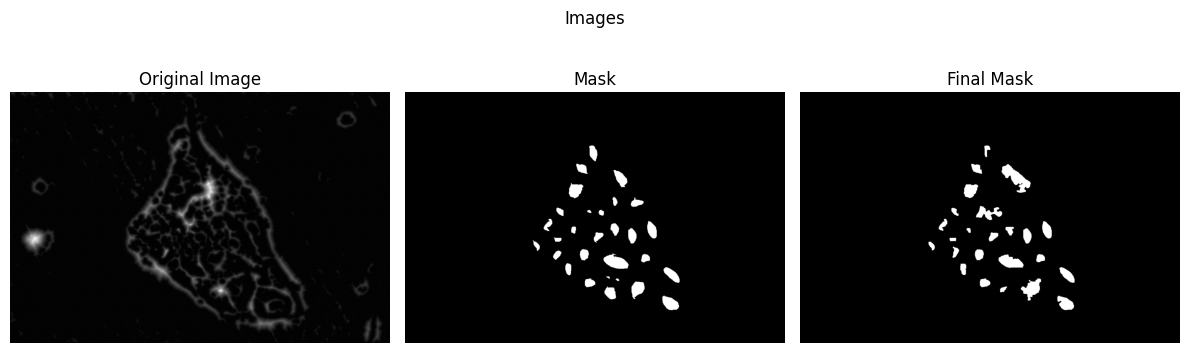

In [ ]:
import math
import heapq
import copy
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.measure import label, regionprops
from numba import jit, prange
from skimage import io

### --- Perona-Malik Diffusion --- ###
def compute_gradients(image):
    grad_north = np.zeros_like(image)
    grad_south = np.zeros_like(image)
    grad_east = np.zeros_like(image)
    grad_west = np.zeros_like(image)

    grad_north[:-1] = image[1:] - image[:-1]
    grad_south[1:] = image[:-1] - image[1:]
    grad_east[:, :-1] = image[:, 1:] - image[:, :-1]
    grad_west[:, 1:] = image[:, :-1] - image[:, 1:]
    return grad_north, grad_south, grad_east, grad_west

def perona_malik_conduction(gradients, kappa, method='quadratic'):
    if method == 'quadratic':
        return [np.exp(-(g / kappa)**2) for g in gradients]
    elif method == 'exponential':
        return [1. / (1. + (g / kappa)**2) for g in gradients]
    raise ValueError("Invalid conduction method.")

@jit(nopython=True, parallel=True)
def update_image(image, gradients, conductance, delta_t):
    result = np.zeros_like(image)
    for i in prange(1, image.shape[0] - 1):
        for j in prange(1, image.shape[1] - 1):
            total = 0.0
            for d in range(4):
                total += conductance[d][i, j] * gradients[d][i, j]
            result[i, j] = total
    return np.clip(image + delta_t * result, 0, 255)

def perona_malik(image, iterations=20, delta_t=0.1, kappa=20, method='quadratic'):
    image = image.astype(np.float64)
    for _ in range(iterations):
        grads = compute_gradients(image)
        conds = perona_malik_conduction(grads, kappa, method)
        image = update_image(image, grads, conds, delta_t)
    return image.astype(np.uint8)

### --- Grey Weighted Distance Transform --- ###
INF = np.finfo(np.float32).max
ALIVE, TRIAL, FAR = -1, 0, 1

def initialize_gwdt(image):
    mean_val = np.mean(image)
    state = np.full_like(image, FAR, dtype=np.int8)
    dist_map = np.full_like(image, INF, dtype=np.float32)
    mask = image < mean_val
    dist_map[mask] = image[mask].astype(float)
    state[mask] = ALIVE
    return state, dist_map

def gwdt(image):
    state, dist = initialize_gwdt(image)
    pq = []
    rows, cols = image.shape

    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            if state[i, j] == FAR and np.any(state[i-1:i+2, j-1:j+2] == ALIVE):
                state[i, j] = TRIAL
                dist[i, j] = float(image[i, j])
                heapq.heappush(pq, (dist[i, j], i, j))

    while pq:
        d, i, j = heapq.heappop(pq)
        for di, dj in [(-1,0), (1,0), (0,-1), (0,1), (-1,-1), (-1,1), (1,-1), (1,1)]:
            ni, nj = i + di, j + dj
            if 0 <= ni < rows and 0 <= nj < cols:
                cost = d + image[ni, nj] * math.hypot(di, dj)
                if dist[ni, nj] > cost:
                    dist[ni, nj] = cost
                    state[ni, nj] = TRIAL
                    heapq.heappush(pq, (cost, ni, nj))

    dist[dist == INF] = 0
    dist = (dist / (np.max(dist) + 1)) * 255 if np.max(dist) > 0 else np.zeros_like(dist)
    return dist.astype(np.uint8)

### --- Chan-Vese Active Contour --- ###
def apply_operation(matrix, op):
    func = {'atan': np.arctan, 'sqrt': np.sqrt}[op]
    return np.vectorize(func)(matrix)

def CV(LSF, img, mu, nu, eps, step):
    Drc = (eps / np.pi) / (eps**2 + LSF**2)
    Hea = 0.5 * (1 + (2 / np.pi) * apply_operation(LSF / eps, "atan"))
    Iy, Ix = np.gradient(LSF)
    s = apply_operation(Ix**2 + Iy**2, "sqrt")
    Nx, Ny = Ix / (s + 1e-6), Iy / (s + 1e-6)
    _, Nxx = np.gradient(Nx)
    Nyy, _ = np.gradient(Ny)
    curv = Nxx + Nyy

    length_term = nu * Drc * curv
    laplace = cv2.Laplacian(LSF, cv2.CV_64F)
    penalty_term = mu * (laplace - curv)

    C1 = np.sum(Hea * img) / np.sum(Hea)
    C2 = np.sum((1 - Hea) * img) / np.sum(1 - Hea)
    cv_term = Drc * (-(img - C1)**2 + (img - C2)**2)

    return LSF + step * (length_term + penalty_term + cv_term)

### --- Image Input Function --- ###
def load_images(image_path, mask_path):
    image = io.imread(image_path, as_gray=True)
    mask = io.imread(mask_path, as_gray=True)
    return image, mask

### --- Segmentation Function --- ###
def segment_image(image, mask, num_iter, mult_factor, mu, nu, eps, step, log_progress=False):

    #working_image = image # choosing image without perona and gwdt

    #patch_filtered = perona_malik(image, iterations=30) # using perona
    #working_image = patch_filtered # choosing with perona without gwdt

    #patch_gwdt = gwdt(image) #using Gwdt
    #working_image = patch_gwdt # choosing GWDT without Perona

    #combining GWDT and perona
    patch_filtered = perona_malik(image, iterations=30)
    patch_gwdt = gwdt(patch_filtered)
    working_image = patch_gwdt

    final_seg = copy.deepcopy(mask)
    nr, nc = image.shape

    for k in range(num_iter):
        hasupdate = 0
        labeled_mask_current = label(final_seg)
        regions = regionprops(labeled_mask_current)

        if not regions:
            print("No regions found based on the initial mask. Exiting segmentation.")
            break

        for kount, region in enumerate(regions):
            minr, minc, maxr, maxc = region.bbox
            h = maxr - minr
            w = maxc - minc

            minr_exp = int(max(0, minr - mult_factor * h))
            maxr_exp = int(min(nr, maxr + mult_factor * h))
            minc_exp = int(max(0, minc - mult_factor * w))
            maxc_exp = int(min(nc, maxc + mult_factor * w))

            if log_progress:
                print("k", k, "i: ", kount, " label", region.label, " dim: ", minr_exp, minc_exp, maxr_exp, maxc_exp)

            image_curr = copy.deepcopy(working_image)
            final_seg_curr = copy.deepcopy(final_seg)
            final_seg_curr[labeled_mask_current != region.label] = 0

            patch = working_image[minr_exp:maxr_exp, minc_exp:maxc_exp]
            mask_patch = final_seg_curr[minr_exp:maxr_exp, minc_exp:maxc_exp]

            if patch.shape[0] == 0 or patch.shape[1] == 0:
                continue

            LSF = np.ones_like(patch, dtype=np.float64)
            LSF[mask_patch > 0] = -1
            patch_float = patch.astype(np.float64)
            LSF_next = CV(LSF, patch_float, mu, nu, eps, step)

            new_seg_patch = (LSF_next < 0).astype(np.uint8)
            new_seg_patch = cv2.morphologyEx(new_seg_patch, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
            loc_lab = label(new_seg_patch)
            loc_lab_props = regionprops(loc_lab)

            for loc_lab_prop in loc_lab_props:
                rc, cc = map(int, loc_lab_prop.centroid)
                if LSF[rc, cc] == -1:
                    loc_lab_lb = loc_lab_prop.label
                    a1, a2, b1, b2 = loc_lab_prop.bbox
                    new_seg_patch[loc_lab != loc_lab_lb] = 0
                    new_seg_patch[a1:b1, a2:b2][loc_lab_prop.image_filled] = 1
                    break

            new_seg_patch = np.uint8(new_seg_patch * 255)
            final_seg[minr_exp:maxr_exp, minc_exp:maxc_exp] = new_seg_patch

    return final_seg

def main():
    # Set file paths
    image_path = "marker1.tif"
    mask_path = "cell1mask.tif"

    # Load image and mask
    image, mask = load_images(image_path, mask_path)

    # Perform segmentation
    final_seg = segment_image(
        image=image,
        mask=mask,
        num_iter=100,
        mult_factor=0.5,
        mu=0.1,
        nu=0.1,
        eps=0.1,
        step=0.1,
        log_progress=False  # Set to True to see iteration logs
    )

    # Save result
    io.imsave("test-cell-segment.tif", final_seg)
    print("Segmentation saved as 'test-cell-segment.tif'.")
    visualize_images([working_image, mask, final_seg], ["Original Image", "Mask", "Final Mask"], "Images")

# Call main if script is run directly
if __name__ == "__main__":
    main()
